In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

!pip install opencv-python scikit-learn matplotlib seaborn pandas -q

# Import libraries
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

tf.keras.backend.clear_session()

np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Libraries imported successfully
TensorFlow version: 2.20.0


In [2]:
# Memory-efficient data generator - loads frames on the fly
class VideoDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, data_path, batch_size=4, target_size=(224, 224), num_frames=30, shuffle=True):
        self.data_path = data_path
        self.batch_size = batch_size
        self.target_size = target_size
        self.num_frames = num_frames
        self.shuffle = shuffle

        # Get all video files and labels
        self.video_paths = []
        self.labels = []

        for class_name, label in [('deepfake', 0), ('real', 1)]:
            class_path = os.path.join(data_path, class_name)
            if os.path.exists(class_path):
                videos = [os.path.join(class_path, f) for f in os.listdir(class_path) if f.endswith('.mp4')]
                self.video_paths.extend(videos)
                self.labels.extend([label] * len(videos))

        self.indices = np.arange(len(self.video_paths))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.video_paths) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_paths = [self.video_paths[i] for i in batch_indices]
        batch_labels = [self.labels[i] for i in batch_indices]

        # Extract frames for this batch only
        batch_frames = []
        for video_path in batch_paths:
            frames = self.extract_frames(video_path)
            batch_frames.append(frames)

        X = np.array(batch_frames)
        y = np.array(batch_labels)

        return X, y

    def extract_frames(self, video_path):
        """Extract frames from a single video"""
        cap = cv2.VideoCapture(video_path)
        frames = []
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        if total_frames > self.num_frames:
            indices = np.linspace(0, total_frames - 1, self.num_frames, dtype=int)
        else:
            indices = range(total_frames)

        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frame = cv2.resize(frame, self.target_size)
                frame = frame / 255.0
                frames.append(frame)

        cap.release()

        # Pad if needed
        while len(frames) < self.num_frames:
            frames.append(np.zeros((self.target_size[0], self.target_size[1], 3)))

        return np.array(frames)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

print("Memory-efficient data generator defined")

Memory-efficient data generator defined


# Load Dataset Statistics

In [3]:
# Define paths
dataset_base = '/content/drive/MyDrive/Dataset_Split'
train_path = os.path.join(dataset_base, 'train')
test_path = os.path.join(dataset_base, 'test')

# Count videos without loading them
def count_videos(data_path):
    counts = {'deepfake': 0, 'real': 0}
    for class_name in ['deepfake', 'real']:
        class_path = os.path.join(data_path, class_name)
        if os.path.exists(class_path):
            counts[class_name] = len([f for f in os.listdir(class_path) if f.endswith('.mp4')])
    return counts

train_counts = count_videos(train_path)
test_counts = count_videos(test_path)

print("="*50)
print("DATASET STATISTICS")
print("="*50)
print(f"Training Set:")
print(f"  Deepfake: {train_counts['deepfake']} videos")
print(f"  Real: {train_counts['real']} videos")
print(f"  Total: {train_counts['deepfake'] + train_counts['real']} videos")
print(f"\nTesting Set:")
print(f"  Deepfake: {test_counts['deepfake']} videos")
print(f"  Real: {test_counts['real']} videos")
print(f"  Total: {test_counts['deepfake'] + test_counts['real']} videos")
print("="*50)

# Create generators (these don't load all videos into memory)
train_generator = VideoDataGenerator(train_path, batch_size=4, target_size=(224, 224), num_frames=30, shuffle=True)
test_generator = VideoDataGenerator(test_path, batch_size=4, target_size=(224, 224), num_frames=30, shuffle=False)

print(f"\nTraining batches: {len(train_generator)}")
print(f"Testing batches: {len(test_generator)}")

DATASET STATISTICS
Training Set:
  Deepfake: 81 videos
  Real: 81 videos
  Total: 162 videos

Testing Set:
  Deepfake: 21 videos
  Real: 21 videos
  Total: 42 videos

Training batches: 41
Testing batches: 11


#Data Visualization

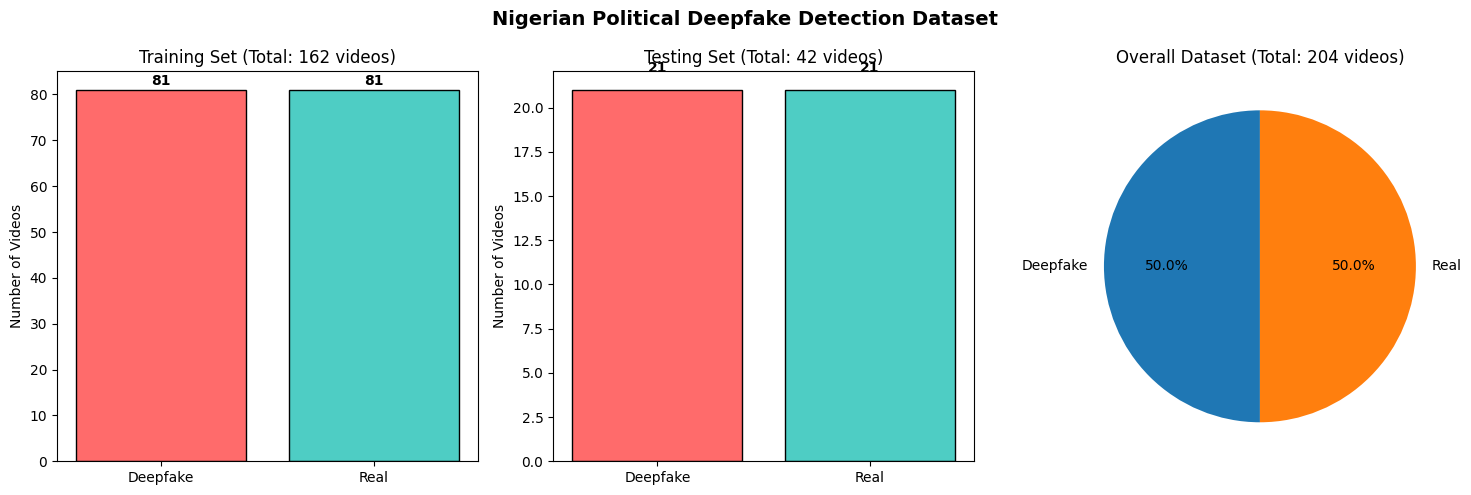

Dataset distribution saved to Drive


In [4]:
# Create dataset distribution charts
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Nigerian Political Deepfake Detection Dataset', fontsize=14, fontweight='bold')

# Training set
train_data = [train_counts['deepfake'], train_counts['real']]
axes[0].bar(['Deepfake', 'Real'], train_data, color=['#ff6b6b', '#4ecdc4'], edgecolor='black')
axes[0].set_title(f'Training Set (Total: {sum(train_data)} videos)')
axes[0].set_ylabel('Number of Videos')
for i, v in enumerate(train_data):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Testing set
test_data = [test_counts['deepfake'], test_counts['real']]
axes[1].bar(['Deepfake', 'Real'], test_data, color=['#ff6b6b', '#4ecdc4'], edgecolor='black')
axes[1].set_title(f'Testing Set (Total: {sum(test_data)} videos)')
axes[1].set_ylabel('Number of Videos')
for i, v in enumerate(test_data):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Overall dataset
overall_data = [train_counts['deepfake'] + test_counts['deepfake'],
                train_counts['real'] + test_counts['real']]
axes[2].pie(overall_data, labels=['Deepfake', 'Real'], autopct='%1.1f%%', startangle=90)
axes[2].set_title(f'Overall Dataset (Total: {sum(overall_data)} videos)')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dataset_distribution.png', dpi=150)
plt.show()
print("Dataset distribution saved to Drive")

# Build Model

In [5]:
def build_lightweight_model(input_shape=(30, 224, 224, 3)):
    """
    Build lightweight video classifier using MobileNetV2
    Uses less memory than ResNet50
    """

    inputs = layers.Input(shape=input_shape, name='video_input')

    # Use TimeDistributed with MobileNetV2 (lighter than ResNet)
    base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
    base_model.trainable = False

    # Apply to each frame
    x = layers.TimeDistributed(base_model)(inputs)
    x = layers.TimeDistributed(layers.GlobalAveragePooling2D())(x)

    # Reduce dimension before LSTM
    x = layers.TimeDistributed(layers.Dense(128, activation='relu'))(x)

    # LSTM for temporal analysis
    x = layers.LSTM(64, return_sequences=False, dropout=0.3)(x)

    # Dense layers
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    # Output
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    return model

# Build model
model = build_lightweight_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC()]
)

model.summary()
print(f"Total parameters: {model.count_params():,}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ video_input (InputLayer)        │ (None, 30, 224, 224,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 7, 7, 1280) │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 30, 1280)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 30, 128)        │       163,968 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,473,473 (9.44 MB)

 Trainable params: 215,489 (841.75 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Total parameters: 2,473,473


# Train Model

In [6]:
callbacks = [
    ModelCheckpoint(
        '/content/drive/MyDrive/best_video_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
]

print("="*50)
print("Starting Training...")
print("="*50)
print(f"Training videos: {train_counts['deepfake'] + train_counts['real']}")
print(f"Testing videos: {test_counts['deepfake'] + test_counts['real']}")
print(f"Batch size: 4")
print(f"Using memory-efficient generator")
print("="*50)

history = model.fit(
    train_generator,
    epochs=30,
    validation_data=test_generator,
    callbacks=callbacks,
    verbose=1
)

print("Training completed successfully")

Starting Training...
Training videos: 162
Testing videos: 42
Batch size: 4
Using memory-efficient generator
Epoch 1/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4753 - auc: 0.5028 - loss: 0.7281 - precision: 0.5313 - recall: 0.3788
Epoch 1: val_accuracy improved from None to 0.76190, saving model to /content/drive/MyDrive/best_video_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/best_video_model.h5
41/41 ━━━━━━━━━━━━━━━━━━━━ 285s 4s/step - accuracy: 0.5123 - auc: 0.5505 - loss: 0.6949 - precision: 0.5128 - recall: 0.4938 - val_accuracy: 0.7619 - val_auc: 0.8787 - val_loss: 0.6329 - val_precision: 0.9231 - val_recall: 0.5714 - learning_rate: 1.0000e-04
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5708 - auc: 0.7027 - loss: 0.6406 - precision: 0.6018 - recall: 0.3717
Epoch 2: val_accuracy improved from 0.76190 to 0.85714, saving model to /content/drive/MyDrive/best_video_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/best_video_model.h5
41/41 ━━━━━━━━━━━━━━━━━━━━ 109s 3s/step - accuracy: 0.6173 - auc: 0.7042 - loss: 0.6355 - precision: 0.6610 - recall: 0.4815 - val_accuracy: 0.8571 - val_auc: 0.9524 - val_loss: 0.5752 - val_precision: 0.8947 - val_recall: 0.8095 - learning_rate: 1.0000e-04
Epoch 3/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8024 - auc: 0.8770 - loss: 0.5393 - precision: 0.8377 - recall: 0.7528
Epoch 3: val_accuracy improved from 0.85714 to 0.90476, saving model to /content/drive/MyDrive/best_video_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/best_video_model.h5
41/41 ━━━━━━━━━━━━━━━━━━━━ 109s 3s/step - accuracy: 0.7407 - auc: 0.8495 - loss: 0.5490 - precision: 0.7910 - recall: 0.6543 - val_accuracy: 0.9048 - val_auc: 0.9932 - val_loss: 0.4415 - val_precision: 1.0000 - val_recall: 0.8095 - learning_rate: 1.0000e-04
Epoch 4/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8371 - auc: 0.8950 - loss: 0.4654 - precision: 0.8332 - recall: 0.7513
Epoch 4: val_accuracy did not improve from 0.90476
41/41 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - accuracy: 0.8519 - auc: 0.9435 - loss: 0.4302 - precision: 0.8800 - recall: 0.8148 - val_accuracy: 0.8810 - val_auc: 0.9955 - val_loss: 0.3482 - val_precision: 1.0000 - val_recall: 0.7619 - learning_rate: 1.0000e-04
Epoch 5/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8873 - auc: 0.9740 - loss: 0.3743 - precision: 0.9417 - recall: 0.8062
Epoch 5: val_accuracy improved from 0.90476 to 0.97619, saving model to /content/drive/


Epoch 5: finished saving model to /content/drive/MyDrive/best_video_model.h5
41/41 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - accuracy: 0.8765 - auc: 0.9648 - loss: 0.3483 - precision: 0.9067 - recall: 0.8395 - val_accuracy: 0.9762 - val_auc: 0.9955 - val_loss: 0.2483 - val_precision: 0.9545 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 6/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9491 - auc: 0.9925 - loss: 0.2771 - precision: 0.9620 - recall: 0.9255
Epoch 6: val_accuracy did not improve from 0.97619
41/41 ━━━━━━━━━━━━━━━━━━━━ 108s 3s/step - accuracy: 0.9568 - auc: 0.9946 - loss: 0.2672 - precision: 0.9744 - recall: 0.9383 - val_accuracy: 0.9762 - val_auc: 1.0000 - val_loss: 0.2045 - val_precision: 1.0000 - val_recall: 0.9524 - learning_rate: 1.0000e-04
Epoch 7/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9824 - auc: 0.9979 - loss: 0.2257 - precision: 0.9882 - recall: 0.9761
Epoch 7: val_accuracy did not improve from 0.97619
41/41 ━━━━━━━━━━━━━━━━━━━━ 108s 3s/s


Epoch 18: finished saving model to /content/drive/MyDrive/best_video_model.h5
41/41 ━━━━━━━━━━━━━━━━━━━━ 108s 3s/step - accuracy: 0.9938 - auc: 0.9997 - loss: 0.0554 - precision: 0.9878 - recall: 1.0000 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0302 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 19/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0413 - precision: 1.0000 - recall: 1.0000
Epoch 19: val_accuracy did not improve from 1.00000
41/41 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0340 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9762 - val_auc: 0.9977 - val_loss: 0.0796 - val_precision: 1.0000 - val_recall: 0.9524 - learning_rate: 1.0000e-04
Epoch 20/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9921 - auc: 0.9977 - loss: 0.0703 - precision: 1.0000 - recall: 0.9851
Epoch 20: val_accuracy did not improve from 1.00000
41/41 ━━━━━━━━━━━━━━━━━━━━ 108s

# Evaluate Model

In [7]:
# Evaluate on test set
print("Evaluating model on test set...")

# Collect all predictions (batch by batch)
y_true = []
y_pred_prob = []

for i in range(len(test_generator)):
    X_batch, y_batch = test_generator[i]
    pred_batch = model.predict(X_batch, verbose=0)
    y_true.extend(y_batch)
    y_pred_prob.extend(pred_batch.flatten())

y_true = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)
y_pred = (y_pred_prob > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc_score = roc_auc_score(y_true, y_pred_prob)
cm = confusion_matrix(y_true, y_pred)

print("="*50)
print("MODEL EVALUATION RESULTS")
print("="*50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc_score:.4f}")
print("="*50)

print("\nConfusion Matrix:")
print(f"               Predicted")
print(f"              Deepfake  Real")
print(f"Actual Deepfake   {cm[0,0]:5d}   {cm[0,1]:5d}")
print(f"Actual Real       {cm[1,0]:5d}   {cm[1,1]:5d}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Deepfake', 'Real']))

Evaluating model on test set...
MODEL EVALUATION RESULTS
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
AUC-ROC:   1.0000

Confusion Matrix:
               Predicted
              Deepfake  Real
Actual Deepfake      21       0
Actual Real           0      21

Classification Report:
              precision    recall  f1-score   support

    Deepfake       1.00      1.00      1.00        21
        Real       1.00      1.00      1.00        21

    accuracy                           1.00        42
   macro avg       1.00      1.00      1.00        42
weighted avg       1.00      1.00      1.00        42



#Visualization of Results

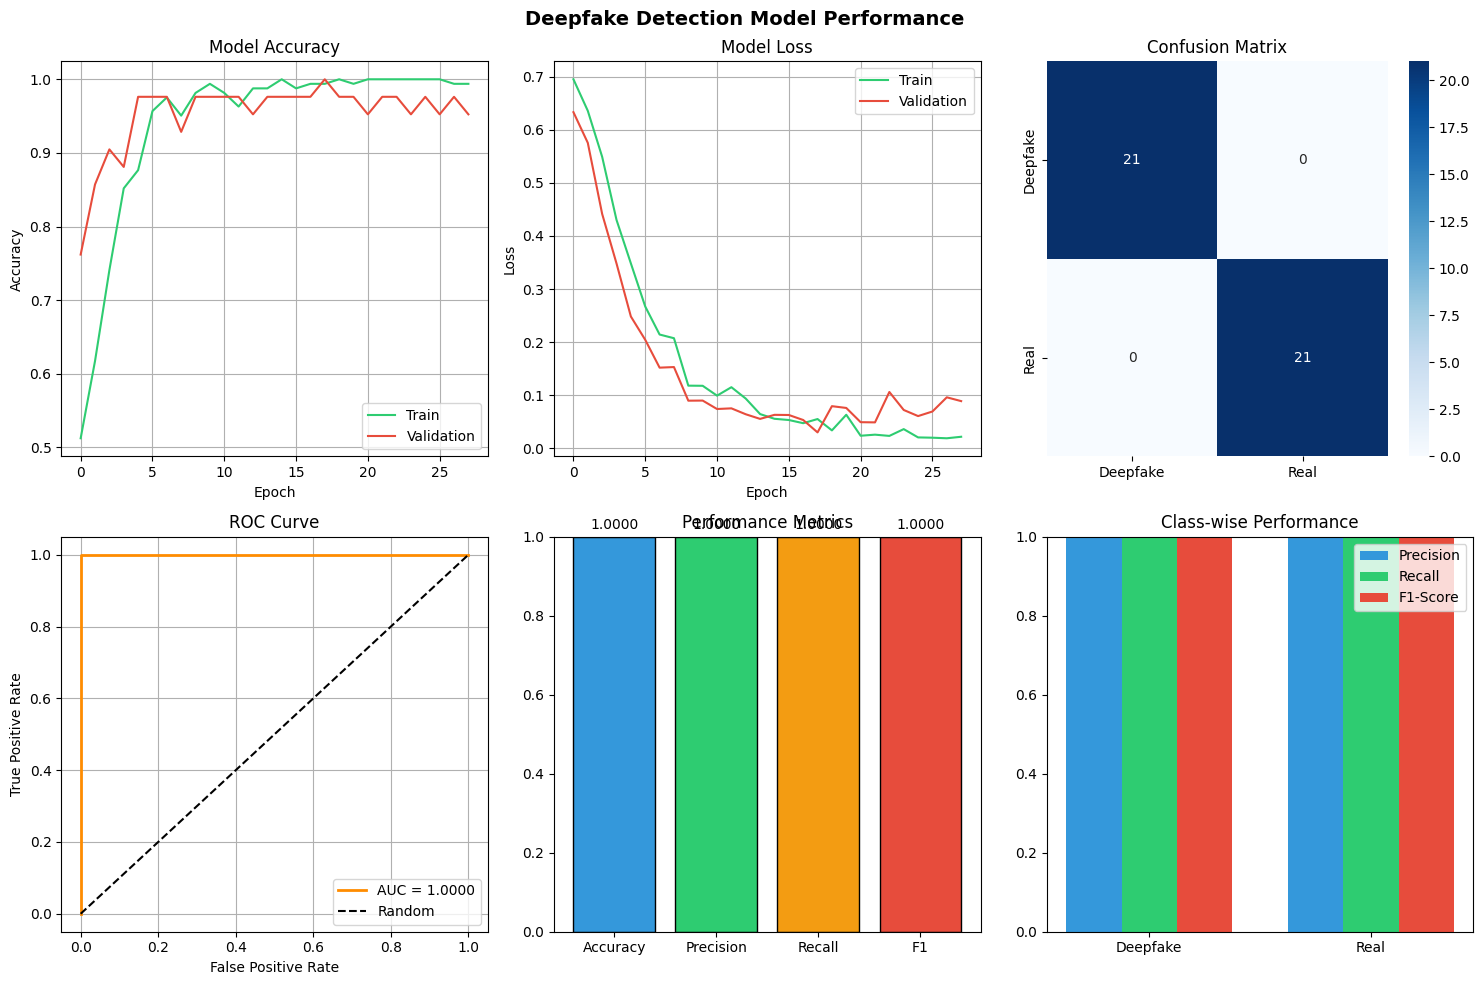

Performance visualization saved to Drive


In [8]:
# Create visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Deepfake Detection Model Performance', fontsize=14, fontweight='bold')

# Accuracy plot
if hasattr(history, 'history'):
    axes[0, 0].plot(history.history['accuracy'], label='Train', color='#2ecc71')
    axes[0, 0].plot(history.history['val_accuracy'], label='Validation', color='#e74c3c')
    axes[0, 0].set_title('Model Accuracy')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

# Loss plot
if hasattr(history, 'history'):
    axes[0, 1].plot(history.history['loss'], label='Train', color='#2ecc71')
    axes[0, 1].plot(history.history['val_loss'], label='Validation', color='#e74c3c')
    axes[0, 1].set_title('Model Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 2],
            xticklabels=['Deepfake', 'Real'],
            yticklabels=['Deepfake', 'Real'])
axes[0, 2].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
axes[1, 0].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc_score:.4f}')
axes[1, 0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1, 0].set_title('ROC Curve')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Metrics Bar Chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
values = [accuracy, precision, recall, f1]
axes[1, 1].bar(metrics, values, color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].set_title('Performance Metrics')
for bar, val in zip(axes[1, 1].patches, values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.4f}', ha='center')

# Class-wise Performance
precision_per_class = precision_score(y_true, y_pred, average=None)
recall_per_class = recall_score(y_true, y_pred, average=None)
f1_per_class = f1_score(y_true, y_pred, average=None)

x = np.arange(2)
width = 0.25
axes[1, 2].bar(x - width, precision_per_class, width, label='Precision', color='#3498db')
axes[1, 2].bar(x, recall_per_class, width, label='Recall', color='#2ecc71')
axes[1, 2].bar(x + width, f1_per_class, width, label='F1-Score', color='#e74c3c')
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(['Deepfake', 'Real'])
axes[1, 2].set_title('Class-wise Performance')
axes[1, 2].set_ylim([0, 1])
axes[1, 2].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/model_performance.png', dpi=150)
plt.show()

print("Performance visualization saved to Drive")

# Save Results

In [9]:
# Save results to CSV
results_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'],
    'Value': [accuracy, precision, recall, f1, auc_score]
})
results_df.to_csv('/content/drive/MyDrive/evaluation_results.csv', index=False)

# Save model
model.save('/content/drive/MyDrive/deepfake_detector_final.h5')
print("Model saved to: /content/drive/MyDrive/deepfake_detector_final.h5")

# Final summary
print("\n" + "="*50)
print("EXPERIMENT COMPLETE")
print("="*50)
print(f"Training videos: {train_counts['deepfake'] + train_counts['real']}")
print(f"Testing videos: {test_counts['deepfake'] + test_counts['real']}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test AUC-ROC: {auc_score:.4f}")
print("="*50)
print("\nFiles saved to Google Drive:")
print("1. best_video_model.h5")
print("2. deepfake_detector_final.h5")
print("3. evaluation_results.csv")
print("4. model_performance.png")
print("5. dataset_distribution.png")

Model saved to: /content/drive/MyDrive/deepfake_detector_final.h5

EXPERIMENT COMPLETE
Training videos: 162
Testing videos: 42
Test Accuracy: 1.0000
Test AUC-ROC: 1.0000

Files saved to Google Drive:
1. best_video_model.h5
2. deepfake_detector_final.h5
3. evaluation_results.csv
4. model_performance.png
5. dataset_distribution.png


# Prediction

Model loaded successfully

LABEL MAPPING (Model Training)
Class 0 (Label 0) = DEEPFAKE (Fake)
Class 1 (Label 1) = REAL (Authentic)

DEEPFAKE DETECTION SYSTEM

Please upload a video file (.mp4)


Saving 595.mp4 to 595 (1).mp4

ANALYZING VIDEO: 595 (1).mp4

Video Information:
  - Duration: 19.00 seconds
  - Total Frames: 475
  - FPS: 25.00
  - Resolution: 640x360

PREDICTION RESULT
Verdict: REAL (Authentic)
Confidence: 97.39%
Model Output Score: 0.973874
Explanation: Model output is HIGH, indicating REAL

Threshold Guide:
  - Score < 0.5: DEEPFAKE
  - Score > 0.5: REAL
  - Score = 0.5: Uncertain


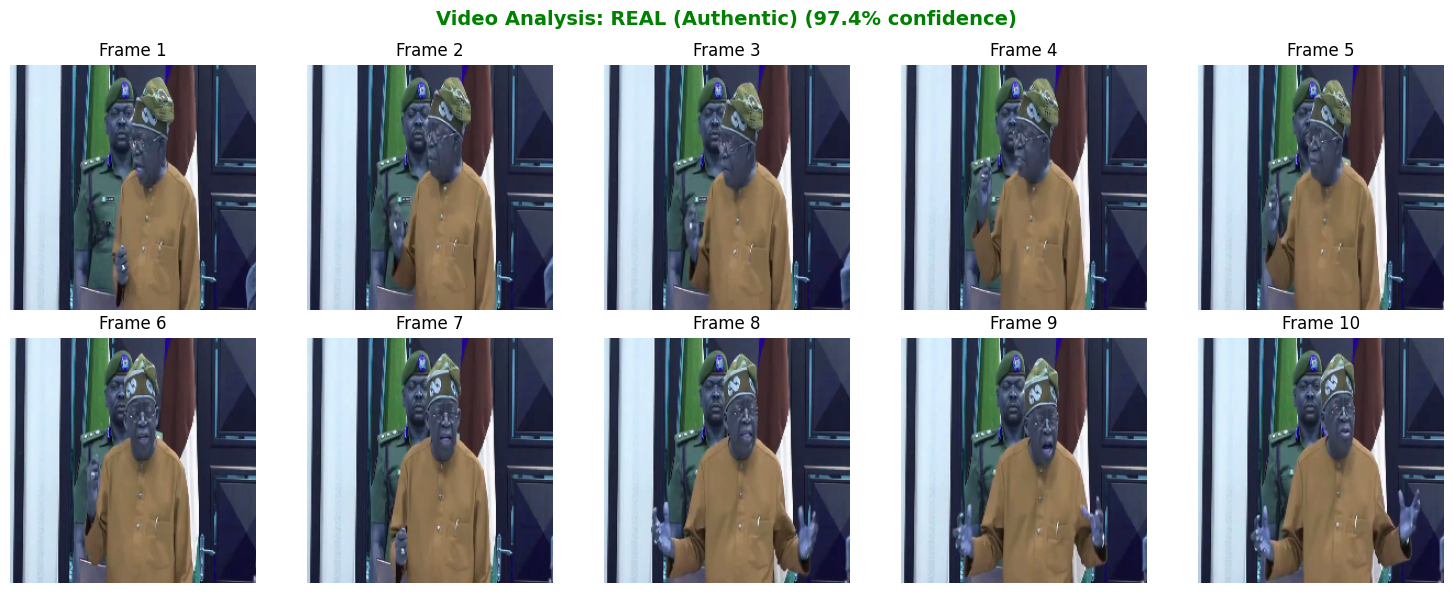


Visualization saved to: /content/drive/MyDrive/prediction_visualization.png

Prediction Complete!


In [14]:
# Deepfake Detection Prediction System - FIXED VERSION
# Correct label mapping: 0 = Deepfake, 1 = Real

import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab import files
from tensorflow.keras.models import load_model

# Load the trained model
model_path = '/content/drive/MyDrive/deepfake_detector_final.h5'
model = load_model(model_path)
print("Model loaded successfully")

print("\n" + "="*60)
print("LABEL MAPPING (Model Training)")
print("="*60)
print("Class 0 (Label 0) = DEEPFAKE (Fake)")
print("Class 1 (Label 1) = REAL (Authentic)")
print("="*60)

# Function to extract frames from uploaded video
def extract_frames_from_video(video_path, num_frames=30, target_size=(224, 224)):
    cap = cv2.VideoCapture(video_path)
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames > num_frames:
        indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    else:
        indices = range(total_frames)

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frame = cv2.resize(frame, target_size)
            frame = frame / 255.0
            frames.append(frame)

    cap.release()

    while len(frames) < num_frames:
        frames.append(np.zeros((target_size[0], target_size[1], 3)))

    return np.array(frames)

# Function to predict video - CORRECTED LOGIC
def predict_video(video_path):
    # Extract frames
    frames = extract_frames_from_video(video_path)
    frames = np.expand_dims(frames, axis=0)

    # Predict
    prediction = model.predict(frames, verbose=0)
    probability = prediction[0][0]

    # CORRECTED: probability is the model's output before threshold
    # The model outputs a value between 0 and 1
    # Lower probability (<0.5) = Deepfake (Class 0)
    # Higher probability (>0.5) = Real (Class 1)

    if probability < 0.5:
        result = "DEEPFAKE (Fake)"
        confidence = (1 - probability) * 100
        color = 'red'
        explanation = "Model output is LOW, indicating DEEPFAKE"
    else:
        result = "REAL (Authentic)"
        confidence = probability * 100
        color = 'green'
        explanation = "Model output is HIGH, indicating REAL"

    return result, confidence, probability, color, explanation

# Upload and predict
print("\n" + "="*60)
print("DEEPFAKE DETECTION SYSTEM")
print("="*60)
print("\nPlease upload a video file (.mp4)")

# Upload file
uploaded = files.upload()

# Process each uploaded file
for filename, content in uploaded.items():
    print(f"\n" + "="*60)
    print(f"ANALYZING VIDEO: {filename}")
    print("="*60)

    # Save uploaded file temporarily
    temp_path = f"/tmp/{filename}"
    with open(temp_path, 'wb') as f:
        f.write(content)

    # Get video info
    cap = cv2.VideoCapture(temp_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    duration = total_frames / fps if fps > 0 else 0
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()

    print(f"\nVideo Information:")
    print(f"  - Duration: {duration:.2f} seconds")
    print(f"  - Total Frames: {total_frames}")
    print(f"  - FPS: {fps:.2f}")
    print(f"  - Resolution: {width}x{height}")

    # Predict
    result, confidence, probability, color, explanation = predict_video(temp_path)

    print(f"\n" + "="*60)
    print(f"PREDICTION RESULT")
    print("="*60)
    print(f"Verdict: {result}")
    print(f"Confidence: {confidence:.2f}%")
    print(f"Model Output Score: {probability:.6f}")
    print(f"Explanation: {explanation}")
    print(f"\nThreshold Guide:")
    print(f"  - Score < 0.5: DEEPFAKE")
    print(f"  - Score > 0.5: REAL")
    print(f"  - Score = 0.5: Uncertain")
    print("="*60)

    # Display sample frames
    frames = extract_frames_from_video(temp_path)

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle(f'Video Analysis: {result} ({confidence:.1f}% confidence)',
                 fontsize=14, fontweight='bold', color=color)

    for i, ax in enumerate(axes.flat):
        if i < len(frames):
            ax.imshow(frames[i])
            ax.set_title(f'Frame {i+1}')
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/prediction_visualization.png', dpi=150)
    plt.show()

    # Cleanup
    os.remove(temp_path)

    print(f"\nVisualization saved to: /content/drive/MyDrive/prediction_visualization.png")

print("\n" + "="*60)
print("Prediction Complete!")
print("="*60)

Model loaded successfully

LABEL MAPPING (Model Training)
Class 0 (Label 0) = DEEPFAKE (Fake)
Class 1 (Label 1) = REAL (Authentic)

DEEPFAKE DETECTION SYSTEM

Please upload a video file (.mp4)


Saving 309.mp4 to 309.mp4

ANALYZING VIDEO: 309.mp4

Video Information:
  - Duration: 17.00 seconds
  - Total Frames: 425
  - FPS: 25.00
  - Resolution: 640x360

PREDICTION RESULT
Verdict: REAL (Authentic)
Confidence: 98.79%
Model Output Score: 0.987860
Threshold Guide: Score < 0.5 = Deepfake, Score > 0.5 = Real


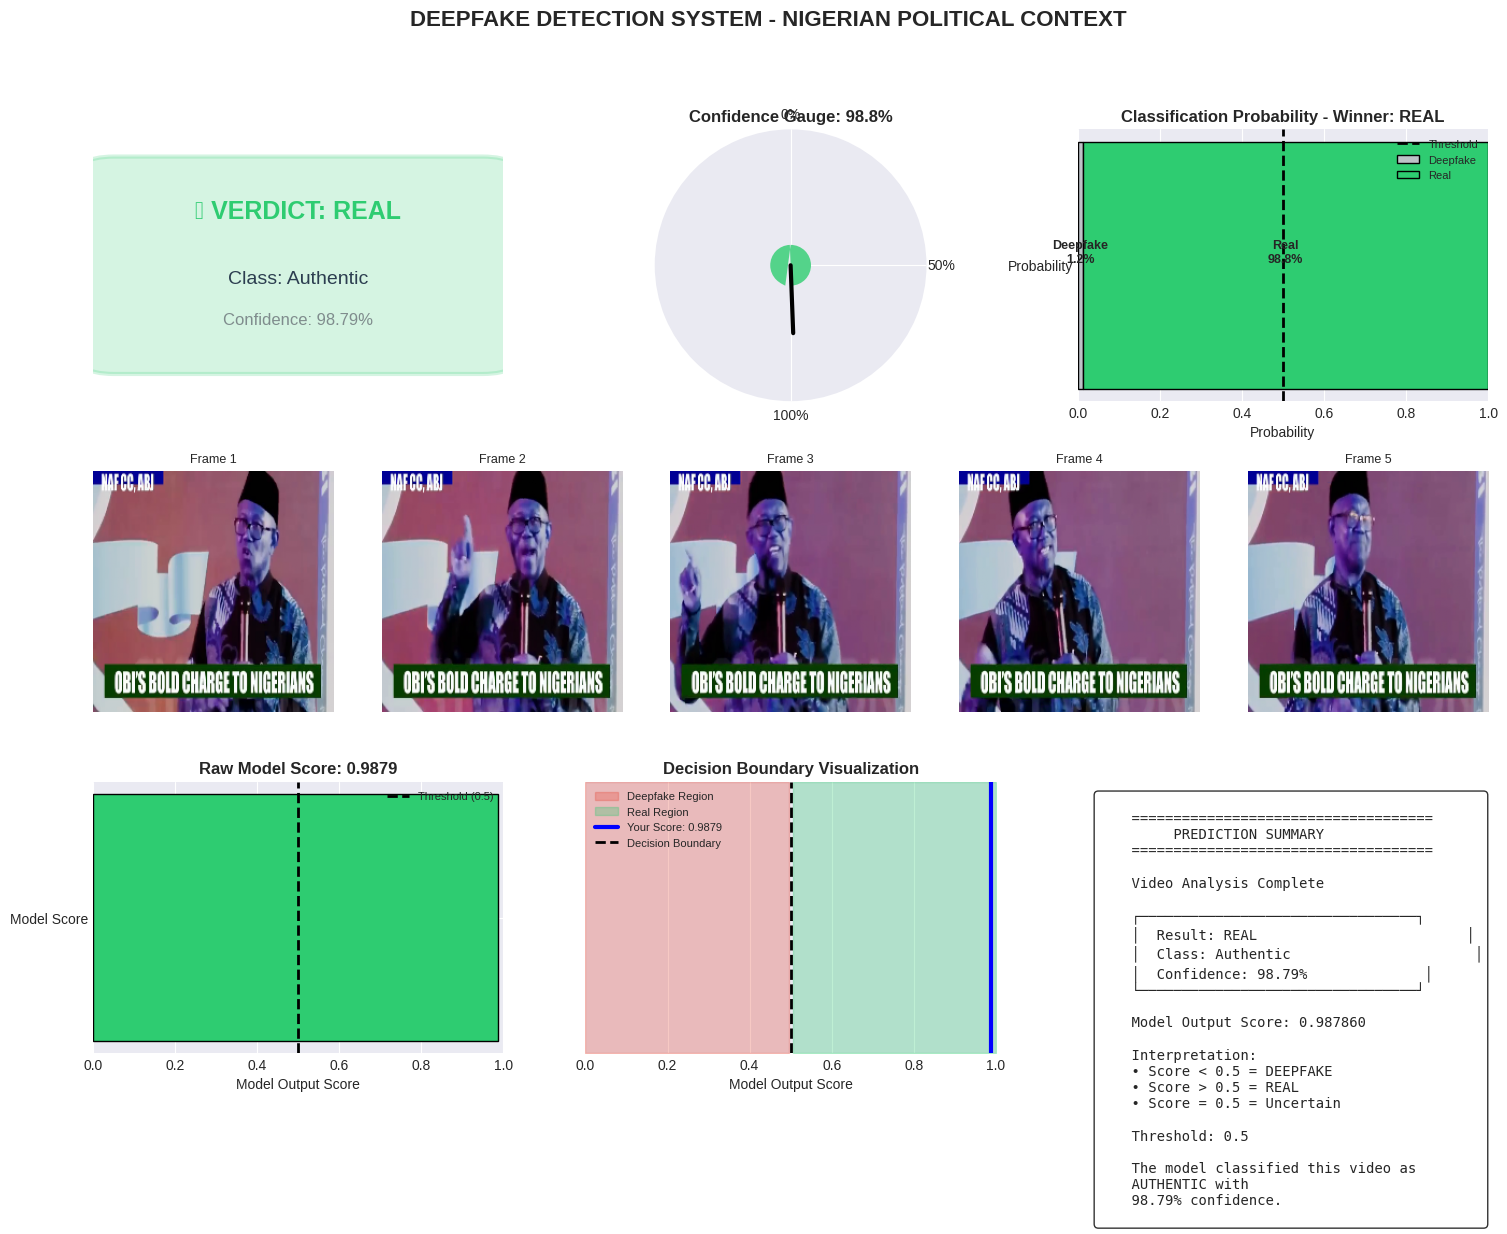


Visualizations saved to:
  - /content/drive/MyDrive/prediction_visualization.png (Full Report)
  - /content/drive/MyDrive/confidence_gauge.png (Gauge Chart)
  - /content/drive/MyDrive/probability_bar.png (Probability Bar)

Prediction Complete!


In [15]:
# Enhanced Deepfake Detection Prediction System with Graphical Visualization
# Correct label mapping: 0 = Deepfake, 1 = Real

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Wedge, Rectangle
from matplotlib.patches import FancyBboxPatch
from google.colab import files
from tensorflow.keras.models import load_model
import warnings
warnings.filterwarnings('ignore')

# Set style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')

# Load the trained model
model_path = '/content/drive/MyDrive/deepfake_detector_final.h5'
model = load_model(model_path)
print("Model loaded successfully")

print("\n" + "="*60)
print("LABEL MAPPING (Model Training)")
print("="*60)
print("Class 0 (Label 0) = DEEPFAKE (Fake)")
print("Class 1 (Label 1) = REAL (Authentic)")
print("="*60)

# Function to extract frames from uploaded video
def extract_frames_from_video(video_path, num_frames=30, target_size=(224, 224)):
    cap = cv2.VideoCapture(video_path)
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames > num_frames:
        indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    else:
        indices = range(total_frames)

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frame = cv2.resize(frame, target_size)
            frame = frame / 255.0
            frames.append(frame)

    cap.release()

    while len(frames) < num_frames:
        frames.append(np.zeros((target_size[0], target_size[1], 3)))

    return np.array(frames)

# Function to predict video
def predict_video(video_path):
    frames = extract_frames_from_video(video_path)
    frames = np.expand_dims(frames, axis=0)
    prediction = model.predict(frames, verbose=0)
    probability = prediction[0][0]

    if probability < 0.5:
        result = "DEEPFAKE"
        result_class = "Fake"
        confidence = (1 - probability) * 100
        color = '#e74c3c'
        bg_color = '#fde8e8'
        icon = "⚠️"
    else:
        result = "REAL"
        result_class = "Authentic"
        confidence = probability * 100
        color = '#2ecc71'
        bg_color = '#e8f8e8'
        icon = "✅"

    return result, result_class, confidence, probability, color, bg_color, icon

# Function to create gauge chart
def create_gauge_chart(probability, title="Confidence Score"):
    fig, ax = plt.subplots(figsize=(6, 4), subplot_kw={'projection': 'polar'})

    # Define gauge parameters
    if probability < 0.5:
        display_value = (1 - probability) * 100
        color = '#e74c3c'
        label = "DEEPFAKE"
    else:
        display_value = probability * 100
        color = '#2ecc71'
        label = "REAL"

    # Create gauge
    theta = np.linspace(0, np.pi, 100)
    r = 0.8 * np.ones_like(theta)

    # Background
    ax.barh(0, np.pi, height=0.3, color='#ecf0f1', left=0)

    # Fill based on confidence
    fill_theta = np.linspace(0, np.pi * (display_value / 100), 100)
    ax.barh(0, fill_theta[-1] if len(fill_theta) > 0 else 0,
            height=0.3, color=color, left=0, alpha=0.8)

    # Add pointer
    pointer_angle = np.pi * (display_value / 100)
    ax.plot([pointer_angle, pointer_angle], [0, 0.5], 'k-', linewidth=3)

    # Formatting
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xticks([0, np.pi/2, np.pi])
    ax.set_xticklabels(['0%', '50%', '100%'])
    ax.set_title(f'{title}: {display_value:.1f}%', fontsize=12, fontweight='bold')

    return fig

# Function to create probability bar chart
def create_probability_bar(probability):
    fig, ax = plt.subplots(figsize=(8, 3))

    # Determine colors
    if probability < 0.5:
        deepfake_color = '#e74c3c'
        real_color = '#bdc3c7'
        deepfake_height = 1 - probability
        real_height = probability
        winner = "DEEPFAKE"
    else:
        deepfake_color = '#bdc3c7'
        real_color = '#2ecc71'
        deepfake_height = 1 - probability
        real_height = probability
        winner = "REAL"

    # Create stacked bar
    bars = ax.barh(['Probability Distribution'], [deepfake_height], color=deepfake_color, label='Deepfake', edgecolor='black')
    bars = ax.barh(['Probability Distribution'], [real_height], left=[deepfake_height], color=real_color, label='Real', edgecolor='black')

    # Add threshold line
    ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold (0.5)')

    # Add labels
    ax.set_xlim(0, 1)
    ax.set_xlabel('Probability', fontsize=11)
    ax.set_title(f'Classification Probability - Winner: {winner}', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right')

    # Add text annotations
    ax.text(deepfake_height/2, 0, f'Deepfake\n{((1-probability)*100):.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.text(deepfake_height + real_height/2, 0, f'Real\n{(probability*100):.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

    return fig

# Function to create comprehensive visualization
def create_comprehensive_visualization(frames, result, result_class, confidence, probability, color, bg_color, icon):
    fig = plt.figure(figsize=(18, 12))
    fig.suptitle('DEEPFAKE DETECTION SYSTEM - NIGERIAN POLITICAL CONTEXT',
                 fontsize=16, fontweight='bold')

    # 1. Result Card (Top Left)
    ax1 = plt.subplot(3, 3, 1)
    ax1.set_facecolor(bg_color)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    ax1.axis('off')

    # Create rounded box
    box = FancyBboxPatch((0.05, 0.2), 0.9, 0.6, boxstyle="round,pad=0.1",
                          facecolor=color, alpha=0.2, edgecolor=color, linewidth=3)
    ax1.add_patch(box)

    ax1.text(0.5, 0.7, f'{icon} VERDICT: {result}', ha='center', va='center',
             fontsize=18, fontweight='bold', color=color)
    ax1.text(0.5, 0.45, f'Class: {result_class}', ha='center', va='center',
             fontsize=14, color='#2c3e50')
    ax1.text(0.5, 0.3, f'Confidence: {confidence:.2f}%', ha='center', va='center',
             fontsize=12, color='#7f8c8d')

    # 2. Gauge Chart (Top Middle)
    ax2 = plt.subplot(3, 3, 2, projection='polar')

    display_value = confidence
    gauge_color = color
    theta = np.linspace(0, np.pi, 100)
    ax2.barh(0, np.pi, height=0.3, color='#ecf0f1', left=0)
    fill_theta = np.linspace(0, np.pi * (display_value / 100), 100)
    if len(fill_theta) > 0:
        ax2.barh(0, fill_theta[-1], height=0.3, color=gauge_color, left=0, alpha=0.8)
    pointer_angle = np.pi * (display_value / 100)
    ax2.plot([pointer_angle, pointer_angle], [0, 0.5], 'k-', linewidth=3)
    ax2.set_theta_zero_location('N')
    ax2.set_theta_direction(-1)
    ax2.set_ylim(0, 1)
    ax2.set_yticks([])
    ax2.set_xticks([0, np.pi/2, np.pi])
    ax2.set_xticklabels(['0%', '50%', '100%'])
    ax2.set_title(f'Confidence Gauge: {display_value:.1f}%', fontsize=12, fontweight='bold')

    # 3. Probability Bar (Top Right)
    ax3 = plt.subplot(3, 3, 3)
    if probability < 0.5:
        deepfake_color = '#e74c3c'
        real_color = '#bdc3c7'
        deepfake_height = 1 - probability
        real_height = probability
        winner = "DEEPFAKE"
    else:
        deepfake_color = '#bdc3c7'
        real_color = '#2ecc71'
        deepfake_height = 1 - probability
        real_height = probability
        winner = "REAL"

    ax3.barh(['Probability'], [deepfake_height], color=deepfake_color, label='Deepfake', edgecolor='black')
    ax3.barh(['Probability'], [real_height], left=[deepfake_height], color=real_color, label='Real', edgecolor='black')
    ax3.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold')
    ax3.set_xlim(0, 1)
    ax3.set_xlabel('Probability')
    ax3.set_title(f'Classification Probability - Winner: {winner}', fontsize=12, fontweight='bold')
    ax3.legend(loc='upper right', fontsize=8)
    ax3.text(deepfake_height/2, 0, f'Deepfake\n{((1-probability)*100):.1f}%',
             ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax3.text(deepfake_height + real_height/2, 0, f'Real\n{(probability*100):.1f}%',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

    # 4. Video Frames (Middle Row - 5 frames)
    num_frames_to_show = min(5, len(frames))
    for i in range(num_frames_to_show):
        ax = plt.subplot(3, 5, 5 + i + 1)
        ax.imshow(frames[i])
        ax.set_title(f'Frame {i+1}', fontsize=9)
        ax.axis('off')

    # 5. Model Score Meter (Bottom Left)
    ax9 = plt.subplot(3, 3, 7)
    meter_color = '#e74c3c' if probability < 0.5 else '#2ecc71'
    ax9.barh(['Model Score'], [probability], color=meter_color, edgecolor='black')
    ax9.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold (0.5)')
    ax9.set_xlim(0, 1)
    ax9.set_xlabel('Model Output Score')
    ax9.set_title(f'Raw Model Score: {probability:.4f}', fontsize=12, fontweight='bold')
    ax9.legend(loc='upper right', fontsize=8)

    # 6. Decision Boundary (Bottom Middle)
    ax10 = plt.subplot(3, 3, 8)
    x = np.linspace(0, 1, 100)
    y = np.ones_like(x)
    ax10.fill_between(x, 0, 1, where=(x<0.5), color='#e74c3c', alpha=0.3, label='Deepfake Region')
    ax10.fill_between(x, 0, 1, where=(x>=0.5), color='#2ecc71', alpha=0.3, label='Real Region')
    ax10.axvline(x=probability, color='blue', linewidth=3, label=f'Your Score: {probability:.4f}')
    ax10.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Decision Boundary')
    ax10.set_xlim(0, 1)
    ax10.set_ylim(0, 1)
    ax10.set_xlabel('Model Output Score')
    ax10.set_title('Decision Boundary Visualization', fontsize=12, fontweight='bold')
    ax10.legend(loc='upper left', fontsize=8)
    ax10.set_yticks([])

    # 7. Summary Statistics (Bottom Right)
    ax11 = plt.subplot(3, 3, 9)
    ax11.axis('off')
    ax11.set_facecolor('#f8f9fa')

    stats_text = f"""
    ====================================
         PREDICTION SUMMARY
    ====================================

    Video Analysis Complete

    ┌─────────────────────────────────┐
    │  Result: {result}                         │
    │  Class: {result_class}                      │
    │  Confidence: {confidence:.2f}%              │
    └─────────────────────────────────┘

    Model Output Score: {probability:.6f}

    Interpretation:
    • Score < 0.5 = DEEPFAKE
    • Score > 0.5 = REAL
    • Score = 0.5 = Uncertain

    Threshold: 0.5

    The model classified this video as
    {result_class.upper()} with
    {confidence:.2f}% confidence.
    """

    ax11.text(0.05, 0.95, stats_text, transform=ax11.transAxes,
              fontsize=10, verticalalignment='top', fontfamily='monospace',
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    return fig

# Main execution
print("\n" + "="*60)
print("DEEPFAKE DETECTION SYSTEM")
print("="*60)
print("\nPlease upload a video file (.mp4)")

uploaded = files.upload()

for filename, content in uploaded.items():
    print(f"\n" + "="*60)
    print(f"ANALYZING VIDEO: {filename}")
    print("="*60)

    temp_path = f"/tmp/{filename}"
    with open(temp_path, 'wb') as f:
        f.write(content)

    # Get video info
    cap = cv2.VideoCapture(temp_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    duration = total_frames / fps if fps > 0 else 0
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()

    print(f"\nVideo Information:")
    print(f"  - Duration: {duration:.2f} seconds")
    print(f"  - Total Frames: {total_frames}")
    print(f"  - FPS: {fps:.2f}")
    print(f"  - Resolution: {width}x{height}")

    # Predict
    frames = extract_frames_from_video(temp_path)
    result, result_class, confidence, probability, color, bg_color, icon = predict_video(temp_path)

    # Display results
    print(f"\n" + "="*60)
    print(f"PREDICTION RESULT")
    print("="*60)
    print(f"Verdict: {result} ({result_class})")
    print(f"Confidence: {confidence:.2f}%")
    print(f"Model Output Score: {probability:.6f}")
    print(f"Threshold Guide: Score < 0.5 = Deepfake, Score > 0.5 = Real")
    print("="*60)

    # Create comprehensive visualization
    fig = create_comprehensive_visualization(frames, result, result_class, confidence, probability, color, bg_color, icon)

    # Save and display
    plt.savefig('/content/drive/MyDrive/prediction_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Also save individual charts
    gauge_fig = create_gauge_chart(probability)
    gauge_fig.savefig('/content/drive/MyDrive/confidence_gauge.png', dpi=150)
    plt.close(gauge_fig)

    bar_fig = create_probability_bar(probability)
    bar_fig.savefig('/content/drive/MyDrive/probability_bar.png', dpi=150)
    plt.close(bar_fig)

    # Cleanup
    os.remove(temp_path)

    print(f"\nVisualizations saved to:")
    print(f"  - /content/drive/MyDrive/prediction_visualization.png (Full Report)")
    print(f"  - /content/drive/MyDrive/confidence_gauge.png (Gauge Chart)")
    print(f"  - /content/drive/MyDrive/probability_bar.png (Probability Bar)")

print("\n" + "="*60)
print("Prediction Complete!")
print("="*60)

Model loaded successfully

LABEL MAPPING (Model Training)
Class 0 (Label 0) = DEEPFAKE (Fake)
Class 1 (Label 1) = REAL (Authentic)

DEEPFAKE DETECTION SYSTEM

Please upload a video file (.mp4)


Saving 095.mp4 to 095.mp4

ANALYZING VIDEO: 095.mp4

Video Information:
  - Duration: 2.00 seconds
  - Total Frames: 60
  - FPS: 30.00
  - Resolution: 534x360

PREDICTION RESULT
Verdict: DEEPFAKE (Fake)
Confidence: 99.78%
Model Output Score: 0.002246
Threshold Guide: Score < 0.5 = Deepfake, Score > 0.5 = Real


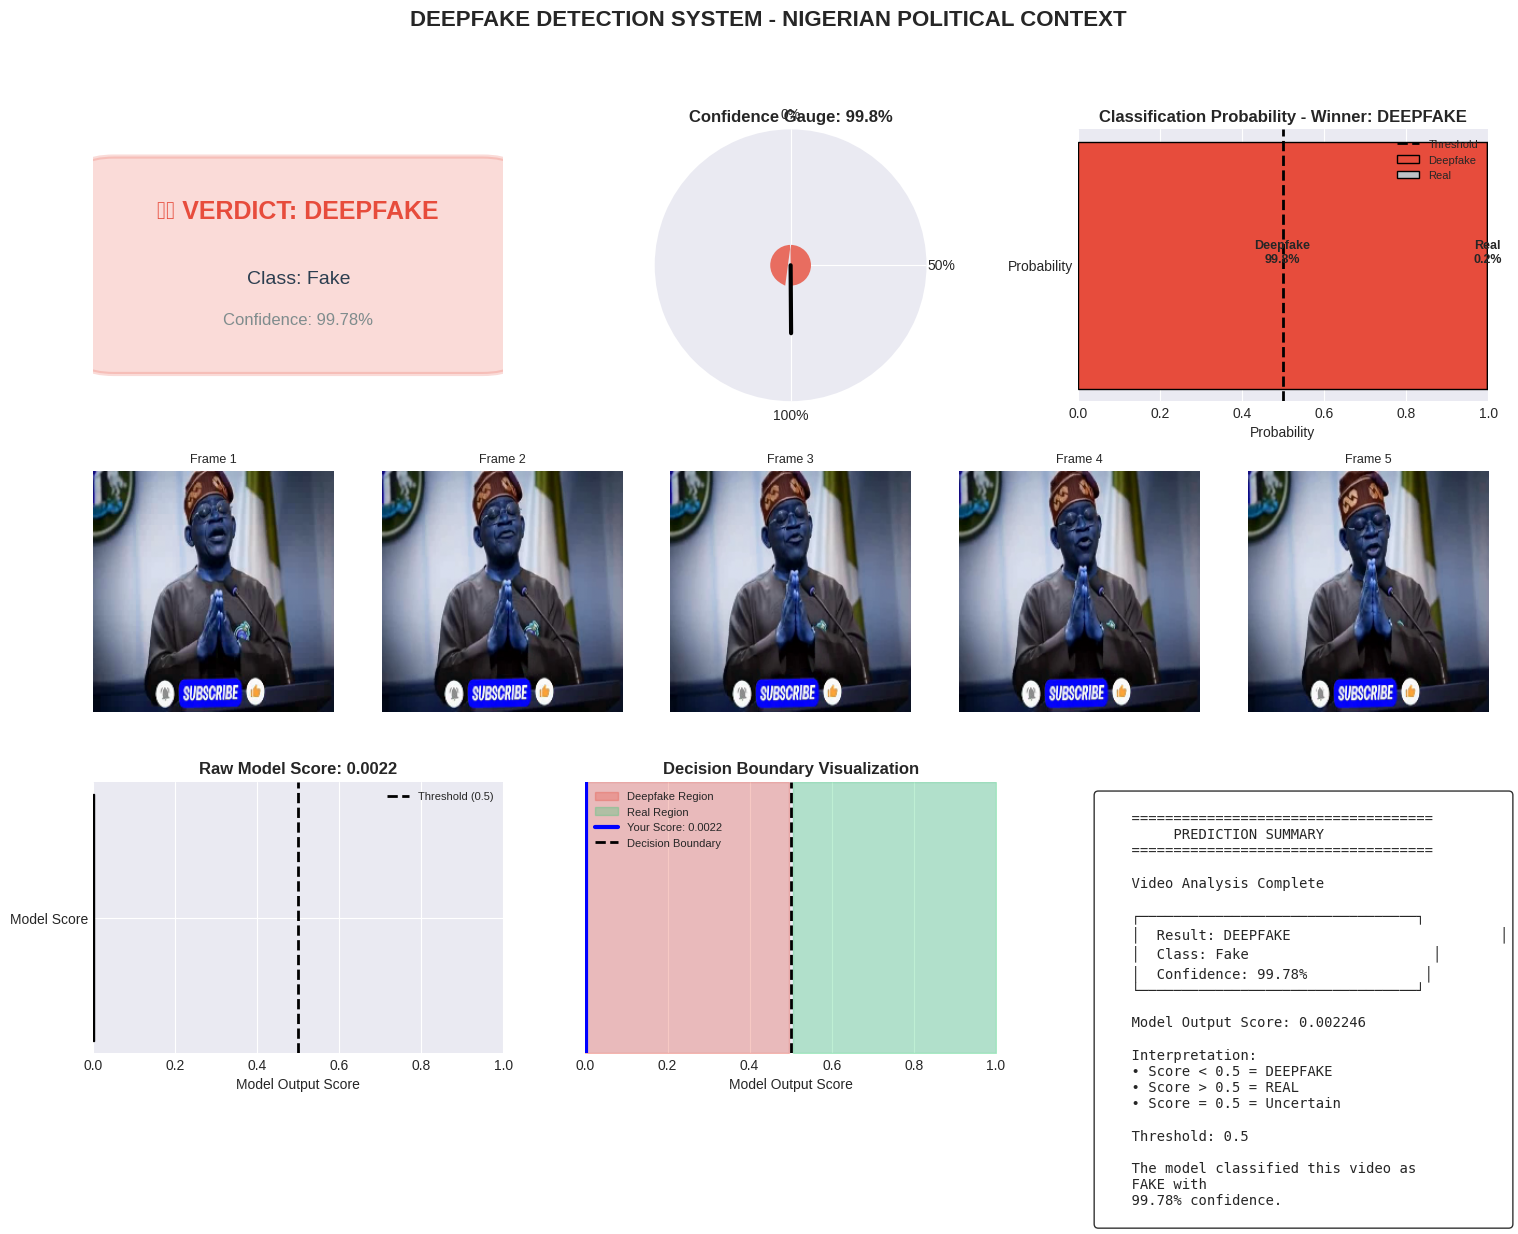


Visualizations saved to:
  - /content/drive/MyDrive/prediction_visualization.png (Full Report)
  - /content/drive/MyDrive/confidence_gauge.png (Gauge Chart)
  - /content/drive/MyDrive/probability_bar.png (Probability Bar)

Prediction Complete!


In [16]:
# Enhanced Deepfake Detection Prediction System with Graphical Visualization
# Correct label mapping: 0 = Deepfake, 1 = Real

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Wedge, Rectangle
from matplotlib.patches import FancyBboxPatch
from google.colab import files
from tensorflow.keras.models import load_model
import warnings
warnings.filterwarnings('ignore')

# Set style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')

# Load the trained model
model_path = '/content/drive/MyDrive/deepfake_detector_final.h5'
model = load_model(model_path)
print("Model loaded successfully")

print("\n" + "="*60)
print("LABEL MAPPING (Model Training)")
print("="*60)
print("Class 0 (Label 0) = DEEPFAKE (Fake)")
print("Class 1 (Label 1) = REAL (Authentic)")
print("="*60)

# Function to extract frames from uploaded video
def extract_frames_from_video(video_path, num_frames=30, target_size=(224, 224)):
    cap = cv2.VideoCapture(video_path)
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames > num_frames:
        indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    else:
        indices = range(total_frames)

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frame = cv2.resize(frame, target_size)
            frame = frame / 255.0
            frames.append(frame)

    cap.release()

    while len(frames) < num_frames:
        frames.append(np.zeros((target_size[0], target_size[1], 3)))

    return np.array(frames)

# Function to predict video
def predict_video(video_path):
    frames = extract_frames_from_video(video_path)
    frames = np.expand_dims(frames, axis=0)
    prediction = model.predict(frames, verbose=0)
    probability = prediction[0][0]

    if probability < 0.5:
        result = "DEEPFAKE"
        result_class = "Fake"
        confidence = (1 - probability) * 100
        color = '#e74c3c'
        bg_color = '#fde8e8'
        icon = "⚠️"
    else:
        result = "REAL"
        result_class = "Authentic"
        confidence = probability * 100
        color = '#2ecc71'
        bg_color = '#e8f8e8'
        icon = "✅"

    return result, result_class, confidence, probability, color, bg_color, icon

# Function to create gauge chart
def create_gauge_chart(probability, title="Confidence Score"):
    fig, ax = plt.subplots(figsize=(6, 4), subplot_kw={'projection': 'polar'})

    # Define gauge parameters
    if probability < 0.5:
        display_value = (1 - probability) * 100
        color = '#e74c3c'
        label = "DEEPFAKE"
    else:
        display_value = probability * 100
        color = '#2ecc71'
        label = "REAL"

    # Create gauge
    theta = np.linspace(0, np.pi, 100)
    r = 0.8 * np.ones_like(theta)

    # Background
    ax.barh(0, np.pi, height=0.3, color='#ecf0f1', left=0)

    # Fill based on confidence
    fill_theta = np.linspace(0, np.pi * (display_value / 100), 100)
    ax.barh(0, fill_theta[-1] if len(fill_theta) > 0 else 0,
            height=0.3, color=color, left=0, alpha=0.8)

    # Add pointer
    pointer_angle = np.pi * (display_value / 100)
    ax.plot([pointer_angle, pointer_angle], [0, 0.5], 'k-', linewidth=3)

    # Formatting
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xticks([0, np.pi/2, np.pi])
    ax.set_xticklabels(['0%', '50%', '100%'])
    ax.set_title(f'{title}: {display_value:.1f}%', fontsize=12, fontweight='bold')

    return fig

# Function to create probability bar chart
def create_probability_bar(probability):
    fig, ax = plt.subplots(figsize=(8, 3))

    # Determine colors
    if probability < 0.5:
        deepfake_color = '#e74c3c'
        real_color = '#bdc3c7'
        deepfake_height = 1 - probability
        real_height = probability
        winner = "DEEPFAKE"
    else:
        deepfake_color = '#bdc3c7'
        real_color = '#2ecc71'
        deepfake_height = 1 - probability
        real_height = probability
        winner = "REAL"

    # Create stacked bar
    bars = ax.barh(['Probability Distribution'], [deepfake_height], color=deepfake_color, label='Deepfake', edgecolor='black')
    bars = ax.barh(['Probability Distribution'], [real_height], left=[deepfake_height], color=real_color, label='Real', edgecolor='black')

    # Add threshold line
    ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold (0.5)')

    # Add labels
    ax.set_xlim(0, 1)
    ax.set_xlabel('Probability', fontsize=11)
    ax.set_title(f'Classification Probability - Winner: {winner}', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right')

    # Add text annotations
    ax.text(deepfake_height/2, 0, f'Deepfake\n{((1-probability)*100):.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.text(deepfake_height + real_height/2, 0, f'Real\n{(probability*100):.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

    return fig

# Function to create comprehensive visualization
def create_comprehensive_visualization(frames, result, result_class, confidence, probability, color, bg_color, icon):
    fig = plt.figure(figsize=(18, 12))
    fig.suptitle('DEEPFAKE DETECTION SYSTEM - NIGERIAN POLITICAL CONTEXT',
                 fontsize=16, fontweight='bold')

    # 1. Result Card (Top Left)
    ax1 = plt.subplot(3, 3, 1)
    ax1.set_facecolor(bg_color)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    ax1.axis('off')

    # Create rounded box
    box = FancyBboxPatch((0.05, 0.2), 0.9, 0.6, boxstyle="round,pad=0.1",
                          facecolor=color, alpha=0.2, edgecolor=color, linewidth=3)
    ax1.add_patch(box)

    ax1.text(0.5, 0.7, f'{icon} VERDICT: {result}', ha='center', va='center',
             fontsize=18, fontweight='bold', color=color)
    ax1.text(0.5, 0.45, f'Class: {result_class}', ha='center', va='center',
             fontsize=14, color='#2c3e50')
    ax1.text(0.5, 0.3, f'Confidence: {confidence:.2f}%', ha='center', va='center',
             fontsize=12, color='#7f8c8d')

    # 2. Gauge Chart (Top Middle)
    ax2 = plt.subplot(3, 3, 2, projection='polar')

    display_value = confidence
    gauge_color = color
    theta = np.linspace(0, np.pi, 100)
    ax2.barh(0, np.pi, height=0.3, color='#ecf0f1', left=0)
    fill_theta = np.linspace(0, np.pi * (display_value / 100), 100)
    if len(fill_theta) > 0:
        ax2.barh(0, fill_theta[-1], height=0.3, color=gauge_color, left=0, alpha=0.8)
    pointer_angle = np.pi * (display_value / 100)
    ax2.plot([pointer_angle, pointer_angle], [0, 0.5], 'k-', linewidth=3)
    ax2.set_theta_zero_location('N')
    ax2.set_theta_direction(-1)
    ax2.set_ylim(0, 1)
    ax2.set_yticks([])
    ax2.set_xticks([0, np.pi/2, np.pi])
    ax2.set_xticklabels(['0%', '50%', '100%'])
    ax2.set_title(f'Confidence Gauge: {display_value:.1f}%', fontsize=12, fontweight='bold')

    # 3. Probability Bar (Top Right)
    ax3 = plt.subplot(3, 3, 3)
    if probability < 0.5:
        deepfake_color = '#e74c3c'
        real_color = '#bdc3c7'
        deepfake_height = 1 - probability
        real_height = probability
        winner = "DEEPFAKE"
    else:
        deepfake_color = '#bdc3c7'
        real_color = '#2ecc71'
        deepfake_height = 1 - probability
        real_height = probability
        winner = "REAL"

    ax3.barh(['Probability'], [deepfake_height], color=deepfake_color, label='Deepfake', edgecolor='black')
    ax3.barh(['Probability'], [real_height], left=[deepfake_height], color=real_color, label='Real', edgecolor='black')
    ax3.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold')
    ax3.set_xlim(0, 1)
    ax3.set_xlabel('Probability')
    ax3.set_title(f'Classification Probability - Winner: {winner}', fontsize=12, fontweight='bold')
    ax3.legend(loc='upper right', fontsize=8)
    ax3.text(deepfake_height/2, 0, f'Deepfake\n{((1-probability)*100):.1f}%',
             ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax3.text(deepfake_height + real_height/2, 0, f'Real\n{(probability*100):.1f}%',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

    # 4. Video Frames (Middle Row - 5 frames)
    num_frames_to_show = min(5, len(frames))
    for i in range(num_frames_to_show):
        ax = plt.subplot(3, 5, 5 + i + 1)
        ax.imshow(frames[i])
        ax.set_title(f'Frame {i+1}', fontsize=9)
        ax.axis('off')

    # 5. Model Score Meter (Bottom Left)
    ax9 = plt.subplot(3, 3, 7)
    meter_color = '#e74c3c' if probability < 0.5 else '#2ecc71'
    ax9.barh(['Model Score'], [probability], color=meter_color, edgecolor='black')
    ax9.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold (0.5)')
    ax9.set_xlim(0, 1)
    ax9.set_xlabel('Model Output Score')
    ax9.set_title(f'Raw Model Score: {probability:.4f}', fontsize=12, fontweight='bold')
    ax9.legend(loc='upper right', fontsize=8)

    # 6. Decision Boundary (Bottom Middle)
    ax10 = plt.subplot(3, 3, 8)
    x = np.linspace(0, 1, 100)
    y = np.ones_like(x)
    ax10.fill_between(x, 0, 1, where=(x<0.5), color='#e74c3c', alpha=0.3, label='Deepfake Region')
    ax10.fill_between(x, 0, 1, where=(x>=0.5), color='#2ecc71', alpha=0.3, label='Real Region')
    ax10.axvline(x=probability, color='blue', linewidth=3, label=f'Your Score: {probability:.4f}')
    ax10.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Decision Boundary')
    ax10.set_xlim(0, 1)
    ax10.set_ylim(0, 1)
    ax10.set_xlabel('Model Output Score')
    ax10.set_title('Decision Boundary Visualization', fontsize=12, fontweight='bold')
    ax10.legend(loc='upper left', fontsize=8)
    ax10.set_yticks([])

    # 7. Summary Statistics (Bottom Right)
    ax11 = plt.subplot(3, 3, 9)
    ax11.axis('off')
    ax11.set_facecolor('#f8f9fa')

    stats_text = f"""
    ====================================
         PREDICTION SUMMARY
    ====================================

    Video Analysis Complete

    ┌─────────────────────────────────┐
    │  Result: {result}                         │
    │  Class: {result_class}                      │
    │  Confidence: {confidence:.2f}%              │
    └─────────────────────────────────┘

    Model Output Score: {probability:.6f}

    Interpretation:
    • Score < 0.5 = DEEPFAKE
    • Score > 0.5 = REAL
    • Score = 0.5 = Uncertain

    Threshold: 0.5

    The model classified this video as
    {result_class.upper()} with
    {confidence:.2f}% confidence.
    """

    ax11.text(0.05, 0.95, stats_text, transform=ax11.transAxes,
              fontsize=10, verticalalignment='top', fontfamily='monospace',
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    return fig

# Main execution
print("\n" + "="*60)
print("DEEPFAKE DETECTION SYSTEM")
print("="*60)
print("\nPlease upload a video file (.mp4)")

uploaded = files.upload()

for filename, content in uploaded.items():
    print(f"\n" + "="*60)
    print(f"ANALYZING VIDEO: {filename}")
    print("="*60)

    temp_path = f"/tmp/{filename}"
    with open(temp_path, 'wb') as f:
        f.write(content)

    # Get video info
    cap = cv2.VideoCapture(temp_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    duration = total_frames / fps if fps > 0 else 0
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()

    print(f"\nVideo Information:")
    print(f"  - Duration: {duration:.2f} seconds")
    print(f"  - Total Frames: {total_frames}")
    print(f"  - FPS: {fps:.2f}")
    print(f"  - Resolution: {width}x{height}")

    # Predict
    frames = extract_frames_from_video(temp_path)
    result, result_class, confidence, probability, color, bg_color, icon = predict_video(temp_path)

    # Display results
    print(f"\n" + "="*60)
    print(f"PREDICTION RESULT")
    print("="*60)
    print(f"Verdict: {result} ({result_class})")
    print(f"Confidence: {confidence:.2f}%")
    print(f"Model Output Score: {probability:.6f}")
    print(f"Threshold Guide: Score < 0.5 = Deepfake, Score > 0.5 = Real")
    print("="*60)

    # Create comprehensive visualization
    fig = create_comprehensive_visualization(frames, result, result_class, confidence, probability, color, bg_color, icon)

    # Save and display
    plt.savefig('/content/drive/MyDrive/prediction_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Also save individual charts
    gauge_fig = create_gauge_chart(probability)
    gauge_fig.savefig('/content/drive/MyDrive/confidence_gauge.png', dpi=150)
    plt.close(gauge_fig)

    bar_fig = create_probability_bar(probability)
    bar_fig.savefig('/content/drive/MyDrive/probability_bar.png', dpi=150)
    plt.close(bar_fig)

    # Cleanup
    os.remove(temp_path)

    print(f"\nVisualizations saved to:")
    print(f"  - /content/drive/MyDrive/prediction_visualization.png (Full Report)")
    print(f"  - /content/drive/MyDrive/confidence_gauge.png (Gauge Chart)")
    print(f"  - /content/drive/MyDrive/probability_bar.png (Probability Bar)")

print("\n" + "="*60)
print("Prediction Complete!")
print("="*60)